In [ ]:
!pip install -q albumentations

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import random, time, os

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

In [6]:
train_transforms = A.Compose([
    A.RandomCrop(32, 32, pad_if_needed=True),
    A.HorizontalFlip(p=0.5),                                         
    A.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1, p=1.0
    ),
    A.Rotate(limit=15),
    A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ToTensorV2(),
])

In [7]:
val_transforms = A.Compose([
    A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ToTensorV2(),
])

In [8]:
class AlbumentationsCIFAR10(Dataset):
    """Wraps torchvision CIFAR-10 to apply Albumentations transforms."""

    def __init__(self, root, train=True, transform=None, download=True):
        self.base = torchvision.datasets.CIFAR10(
            root=root, train=train, download=download
        )
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        img = np.array(img)                     # PIL → numpy HWC uint8
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

In [9]:
def make_subset(dataset, fraction: float, seed: int = SEED):
    """Return a Subset of *fraction* of *dataset*, stratified-ish."""
    n = int(len(dataset) * fraction)
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=n, replace=False).tolist()
    return Subset(dataset, indices)

In [10]:
DATA_DIR   = "/kaggle/working/data"
BATCH_SIZE = 64
NUM_WORKERS = 2

In [11]:
full_train = AlbumentationsCIFAR10(DATA_DIR, train=True,  transform=train_transforms)
val_set    = AlbumentationsCIFAR10(DATA_DIR, train=False, transform=val_transforms)

100%|██████████| 170M/170M [03:04<00:00, 926kB/s] 


In [13]:
subset_10  = make_subset(full_train, fraction=0.10)
subset_25  = make_subset(full_train, fraction=0.25)
subset_50  = make_subset(full_train, fraction=0.50)

In [14]:
loaders = {
    "10%":  DataLoader(subset_10,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "25%":  DataLoader(subset_25,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "50%":  DataLoader(subset_25,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "100%": DataLoader(full_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
}
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [15]:
print("Dataset sizes:")
for k, dl in loaders.items():
    print(f"  {k:5s} → {len(dl.dataset):,} samples, {len(dl):,} batches/epoch")
print(f"  {'val':5s} → {len(val_set):,} samples")

Dataset sizes:
  10%   → 5,000 samples, 79 batches/epoch
  25%   → 12,500 samples, 196 batches/epoch
  50%   → 12,500 samples, 196 batches/epoch
  100%  → 50,000 samples, 782 batches/epoch
  val   → 10,000 samples


In [16]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3,   32,  kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32,  64,  kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1, bias=False),  
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                       
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                 
            nn.Dropout(p=dropout),
            nn.Linear(128 * 4 * 4, num_classes),                        
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x


In [17]:
def build_model(num_classes=10):
    model = CIFAR10_CNN(num_classes=num_classes, dropout=0.5).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")
    return model

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, 100.0 * correct / total

In [19]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, 100.0 * correct / total

In [24]:
def run_experiment(subset_name, num_epochs=30):
    print(f"\n{'='*55}")
    print(f"  Experiment: {subset_name} subset  ({num_epochs} epochs)")
    print(f"{'='*55}")

    loader   = loaders[subset_name]
    model    = build_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.amp.GradScaler('cuda')

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, loader, criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:3d}/{num_epochs} | "
                f"Train loss {tr_loss:.4f}  acc {tr_acc:.1f}% | "
                f"Val loss {vl_loss:.4f}  acc {vl_acc:.1f}% | "
                f"{elapsed:.1f}s"
            )

    best_val = max(history["val_acc"])
    print(f"\n  ✓ Best val accuracy: {best_val:.2f}%")

    ckpt_path = f"/kaggle/working/cnn4layer_{subset_name.replace('%','pct')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    return history, best_val

In [25]:
EPOCHS = 30          

results = {}
for subset in ["10%", "25%", "50%", "100%"]:         
    hist, best = run_experiment(subset, num_epochs=EPOCHS)
    results[subset] = {"history": hist, "best_val_acc": best}


  Experiment: 10% subset  (30 epochs)
Trainable parameters: 113,962
  Epoch   1/30 | Train loss 2.0952  acc 30.1% | Val loss 1.7589  acc 43.1% | 3.6s
  Epoch   5/30 | Train loss 1.6330  acc 49.6% | Val loss 1.5052  acc 55.8% | 3.5s
  Epoch  10/30 | Train loss 1.4373  acc 58.6% | Val loss 1.3400  acc 63.8% | 3.7s
  Epoch  15/30 | Train loss 1.3120  acc 65.1% | Val loss 1.3612  acc 63.2% | 3.6s
  Epoch  20/30 | Train loss 1.2232  acc 69.3% | Val loss 1.2367  acc 69.5% | 3.5s
  Epoch  25/30 | Train loss 1.1658  acc 72.8% | Val loss 1.2164  acc 70.0% | 3.5s
  Epoch  30/30 | Train loss 1.1543  acc 72.7% | Val loss 1.2060  acc 70.5% | 3.5s

  ✓ Best val accuracy: 70.62%

  Experiment: 25% subset  (30 epochs)
Trainable parameters: 113,962
  Epoch   1/30 | Train loss 1.9291  acc 35.3% | Val loss 1.6037  acc 50.4% | 6.4s
  Epoch   5/30 | Train loss 1.4508  acc 58.0% | Val loss 1.3426  acc 63.9% | 6.4s
  Epoch  10/30 | Train loss 1.2927  acc 66.2% | Val loss 1.2675  acc 67.3% | 6.4s
  Epoch  15

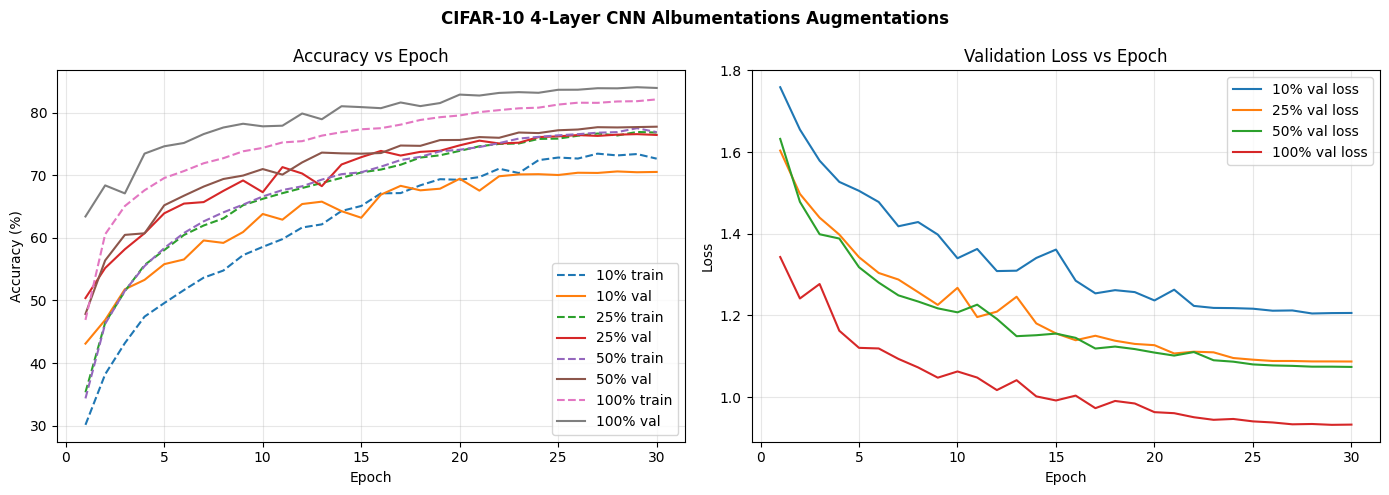

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, data in results.items():
    h = data["history"]
    epochs = range(1, len(h["val_acc"]) + 1)
    axes[0].plot(epochs, h["train_acc"], linestyle="--", label=f"{label} train")
    axes[0].plot(epochs, h["val_acc"],   linestyle="-",  label=f"{label} val")
    axes[1].plot(epochs, h["val_loss"],  linestyle="-",  label=f"{label} val loss")

axes[0].set_title("Accuracy vs Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Loss vs Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("CIFAR-10 4-Layer CNN Albumentations Augmentations", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [27]:
print("\n" + "─"*40)
print(f"{'Subset':>8}  {'Best Val Acc':>13}  {'Train Samples':>14}")
print("─"*40)
for subset, data in results.items():
    n = len(loaders[subset].dataset)
    print(f"{subset:>8}  {data['best_val_acc']:>12.2f}%  {n:>14,}")
print("─"*40)


────────────────────────────────────────
  Subset   Best Val Acc   Train Samples
────────────────────────────────────────
     10%         70.62%           5,000
     25%         76.58%          12,500
     50%         77.77%          12,500
    100%         84.08%          50,000
────────────────────────────────────────
